In [ ]:
!pip install seqeval

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from collections import Counter, defaultdict
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report
from sklearn.metrics import confusion_matrix

SEED           = 42
MODEL_NAME     = "dslim/bert-base-NER"
DATASET_NAME   = "tner/conll2003"
CONTEXT_WINDOW = 2
WE, WC, WO     = 1.0, 1.0, 0.01
HIGH_THRESH    = 0.80
LOW_THRESH     = 0.10
MIN_FREQ       = 5
MAX_LEN        = 256
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Device: {DEVICE}")

Device: cuda


## 1. Загрузка данных

In [ ]:
raw = load_dataset("lhoestq/conll2003")

feat = raw["train"].features["ner_tags"].feature
LABEL_NAMES = feat.names if hasattr(feat, "names") else [
    "O", "B-PER", "I-PER", "B-ORG", "I-ORG",
    "B-LOC", "I-LOC", "B-MISC", "I-MISC",
]

train_ds = raw["train"]
val_ds   = raw["validation"]
test_ds  = raw["test"]

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
print(f"Labels: {LABEL_NAMES}")

ex = train_ds[4]
for tok, tid in zip(ex["tokens"], ex["ner_tags"]):
    print(f"  {tok:15} {LABEL_NAMES[tid]}")

Train: 14041, Val: 3250, Test: 3453
Labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
  Germany         B-LOC
  's              O
  representative  O
  to              O
  the             O
  European        B-ORG
  Union           I-ORG
  's              O
  veterinary      O
  committee       O
  Werner          B-PER
  Zwingmann       I-PER
  said            O
  on              O
  Wednesday       O
  consumers       O
  should          O
  buy             O
  sheepmeat       O
  from            O
  countries       O
  other           O
  than            O
  Britain         B-LOC
  until           O
  the             O
  scientific      O
  advice          O
  was             O
  clearer         O
  .               O


## 2. Статистика датасета

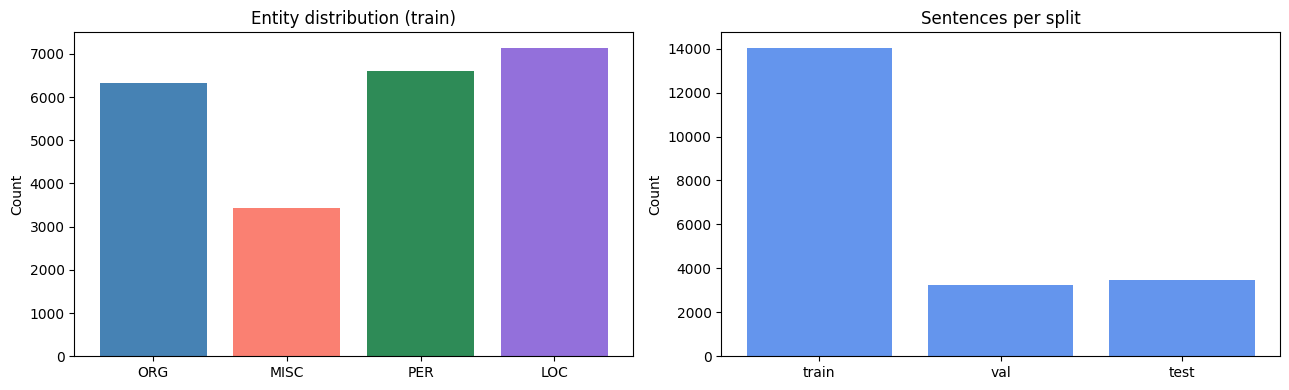

In [ ]:
ent_counts = Counter()
for ex in train_ds:
    for tid in ex["ner_tags"]:
        lbl = LABEL_NAMES[tid]
        if lbl.startswith("B-"):
            ent_counts[lbl[2:]] += 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(ent_counts.keys(), ent_counts.values(),
            color=["steelblue", "salmon", "seagreen", "mediumpurple"])
axes[0].set_title("Entity distribution (train)")
axes[0].set_ylabel("Count")

splits = {"train": len(train_ds), "val": len(val_ds), "test": len(test_ds)}
axes[1].bar(splits.keys(), splits.values(), color="cornflowerblue")
axes[1].set_title("Sentences per split")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 3. Трёхклассовая статистика токенов (Step 0 из DEER)


In [ ]:
def build_token_stats(dataset, label_names, window=CONTEXT_WINDOW):
    entity_cnt   = defaultdict(int)
    context_cnt  = defaultdict(int)
    other_cnt    = defaultdict(int)
    ent_type_cnt = defaultdict(Counter)

    for ex in dataset:
        tokens = ex["tokens"]
        tags   = [label_names[t] for t in ex["ner_tags"] ]

        ent_pos = {i for i, t in enumerate(tags) if t != "O"}

        ctx_pos = set()
        for p in ent_pos:
            for d in range(-window, window + 1):
                nb = p + d
                if 0 <= nb < len(tokens) and nb not in ent_pos:
                    ctx_pos.add(nb)

        for i, (tok, tag) in enumerate(zip(tokens, tags)):
            key = tok.lower()
            if i in ent_pos:
                entity_cnt[key] += 1
                ent_type_cnt[key][tag.split("-")[-1]] += 1
            elif i in ctx_pos:
                context_cnt[key] += 1
            else:
                other_cnt[key] += 1

    all_toks = set(entity_cnt) | set(context_cnt) | set(other_cnt)
    stats = {}
    for tok in all_toks:
        e, c, o = entity_cnt[tok], context_cnt[tok], other_cnt[tok]
        total   = e + c + o
        best    = ent_type_cnt[tok].most_common(1)[0][0] if tok in ent_type_cnt else None
        stats[tok] = {
            "entity": e, "context": c, "other": o, "total": total,
            "p_e": e / total, "p_c": c / total, "p_o": o / total,
            "best_type": best,
        }
    return stats

token_stats = build_token_stats(train_ds, LABEL_NAMES)
print(f"Уникальных токенов: {len(token_stats)}")

Уникальных токенов: 21009


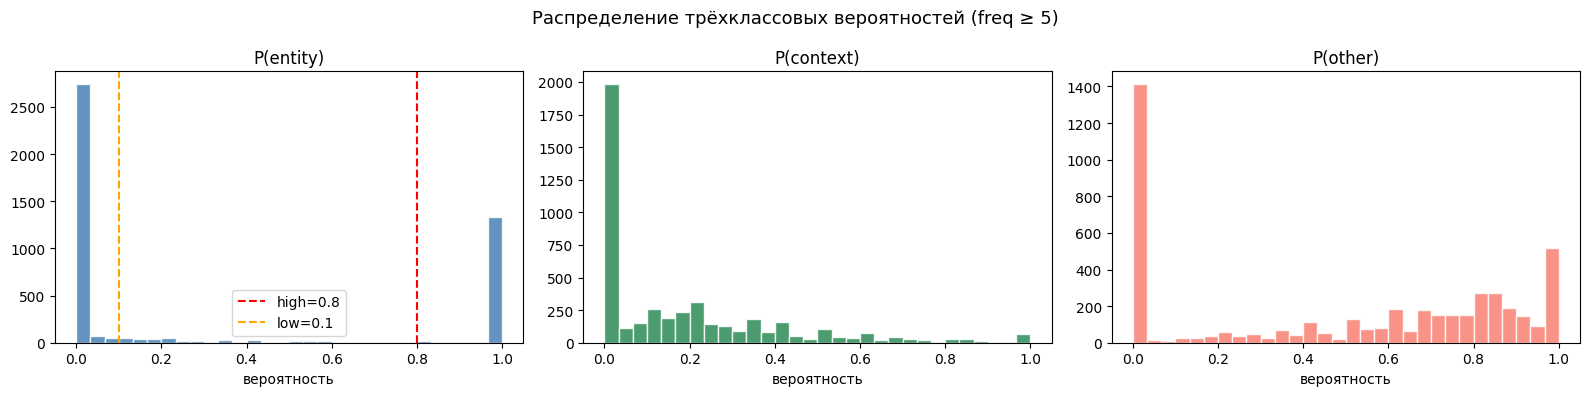

Токенов с p_e >= 0.8: 1380
Токенов с p_e <= 0.1:  2863


In [ ]:
freq_rows = [
    {"token": t, **v}
    for t, v in token_stats.items()
    if v["total"] >= MIN_FREQ
]
stats_df = pd.DataFrame(freq_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(stats_df["p_e"], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(HIGH_THRESH, color="red",    linestyle="--", label=f"high={HIGH_THRESH}")
axes[0].axvline(LOW_THRESH,  color="orange", linestyle="--", label=f"low={LOW_THRESH}")
axes[0].set_title("P(entity)")
axes[0].set_xlabel("вероятность")
axes[0].legend()

axes[1].hist(stats_df["p_c"], bins=30, color="seagreen", edgecolor="white", alpha=0.85)
axes[1].set_title("P(context)")
axes[1].set_xlabel("вероятность")

axes[2].hist(stats_df["p_o"], bins=30, color="salmon", edgecolor="white", alpha=0.85)
axes[2].set_title("P(other)")
axes[2].set_xlabel("вероятность")

fig.suptitle("Распределение трёхклассовых вероятностей (freq ≥ 5)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Токенов с p_e >= {HIGH_THRESH}: {(stats_df['p_e'] >= HIGH_THRESH).sum()}")
print(f"Токенов с p_e <= {LOW_THRESH}:  {(stats_df['p_e'] <= LOW_THRESH).sum()}")

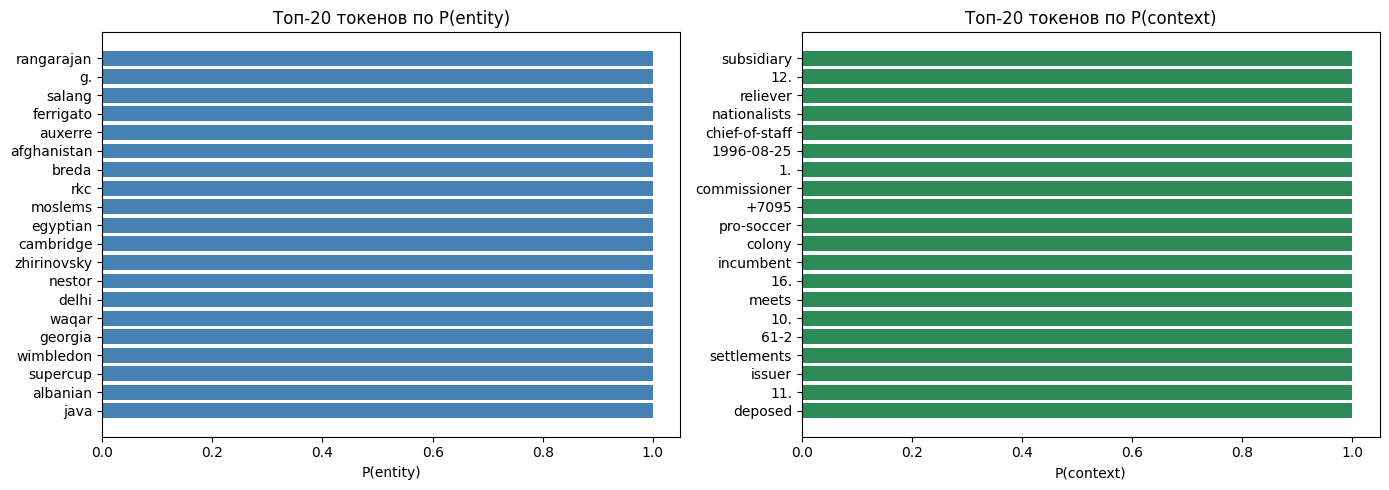

In [ ]:
top20_ent = stats_df.nlargest(20, "p_e")
top20_ctx = stats_df.nlargest(20, "p_c")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top20_ent["token"].values, top20_ent["p_e"].values, color="steelblue")
axes[0].set_xlabel("P(entity)")
axes[0].set_title("Топ-20 токенов по P(entity)")
axes[0].invert_yaxis()

axes[1].barh(top20_ctx["token"].values, top20_ctx["p_c"].values, color="seagreen")
axes[1].set_xlabel("P(context)")
axes[1].set_title("Топ-20 токенов по P(context)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Загрузка модели

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForTokenClassification.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

id2label = model.config.id2label
print("Model labels:", id2label)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model labels: {0: 'O', 1: 'B-MISC', 2: 'I-MISC', 3: 'B-PER', 4: 'I-PER', 5: 'B-ORG', 6: 'I-ORG', 7: 'B-LOC', 8: 'I-LOC'}


## 5. Инференс и DEER-коррекция


In [ ]:
def predict(tokens):
    enc = tokenizer(
        tokens,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN
    ).to(DEVICE)

    with torch.no_grad():
        logits = model(**enc).logits[0].cpu().numpy()

    word_ids = enc.word_ids(0)
    preds, seen = [], None
    for wid, lid in zip(word_ids, logits.argmax(-1)):
        if wid is None or wid == seen:
            continue
        seen = wid
        preds.append(id2label[int(lid)])

    preds = preds[:len(tokens)]
    preds += ["O"] * (len(tokens) - len(preds))
    return preds

In [ ]:
def deer_correct(tokens, base_preds, stats, high=HIGH_THRESH, low=LOW_THRESH,
                 min_freq=MIN_FREQ, we=WE, wc=WC, wo=WO):
    result = base_preds[:]

    for i, (tok, pred) in enumerate(zip(tokens, base_preds)):
        s = stats.get(tok.lower())
        if s is None or s["total"] < min_freq:
            continue

        ent_type = s["best_type"]

        if pred == "O" and s["p_e"] >= high and ent_type:
            result[i] = f"B-{ent_type}"

        elif pred != "O" and s["p_e"] <= low and s["p_o"] > s["p_c"]:
            result[i] = "O"

    return result


## 6. Оценка на тестовой выборке

In [ ]:
y_true, y_base, y_deer = [], [], []
changed, total_toks = 0, 0

for i, ex in enumerate(test_ds):
    tokens = ex["tokens"]
    gold   = [LABEL_NAMES[t] for t in ex["ner_tags"]]
    base   = predict(tokens)
    deer   = deer_correct(tokens, base, token_stats)

    y_true.append(gold)
    y_base.append(base)
    y_deer.append(deer)

    for b, d in zip(base, deer):
        changed    += int(b != d)
        total_toks += 1

    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/{len(test_ds)}")

print(f"\nИзменено токенов: {changed}/{total_toks} ({100*changed/total_toks:.2f}%)")

  500/3453
  1000/3453
  1500/3453
  2000/3453
  2500/3453
  3000/3453

Изменено токенов: 322/46435 (0.69%)


## 7. Результаты

In [ ]:
metrics = {
    "Baseline": {
        "F1":        f1_score(y_true, y_base),
        "Precision": precision_score(y_true, y_base),
        "Recall":    recall_score(y_true, y_base),
    },
    "DEER (3-class)": {
        "F1":        f1_score(y_true, y_deer),
        "Precision": precision_score(y_true, y_deer),
        "Recall":    recall_score(y_true, y_deer),
    },
}

results_df = pd.DataFrame(metrics).T
results_df["ΔF1"] = results_df["F1"] - results_df.loc["Baseline", "F1"]
display(results_df.round(4))

,F1,Precision,Recall,ΔF1
Baseline,0.9129,0.9066,0.9193,0.0000
DEER (3-class),0.8818,0.8650,0.8993,-0.0311


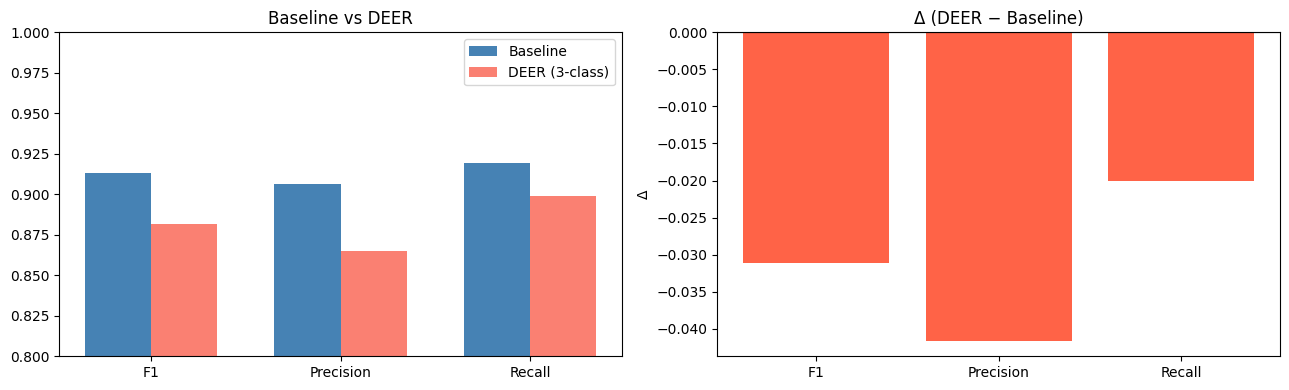

In [ ]:
metric_names = ["F1", "Precision", "Recall"]
x = np.arange(len(metric_names))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(x - w/2, [metrics["Baseline"][m]        for m in metric_names], w, label="Baseline",        color="steelblue")
axes[0].bar(x + w/2, [metrics["DEER (3-class)"][m]  for m in metric_names], w, label="DEER (3-class)", color="salmon")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names)
axes[0].set_ylim(0.8, 1.0)
axes[0].set_title("Baseline vs DEER")
axes[0].legend()

delta  = [metrics["DEER (3-class)"][m] - metrics["Baseline"][m] for m in metric_names]
colors = ["seagreen" if d >= 0 else "tomato" for d in delta]
axes[1].bar(metric_names, delta, color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Δ (DEER − Baseline)")
axes[1].set_ylabel("Δ")

plt.tight_layout()
plt.show()

## 8. Confusion Matrix

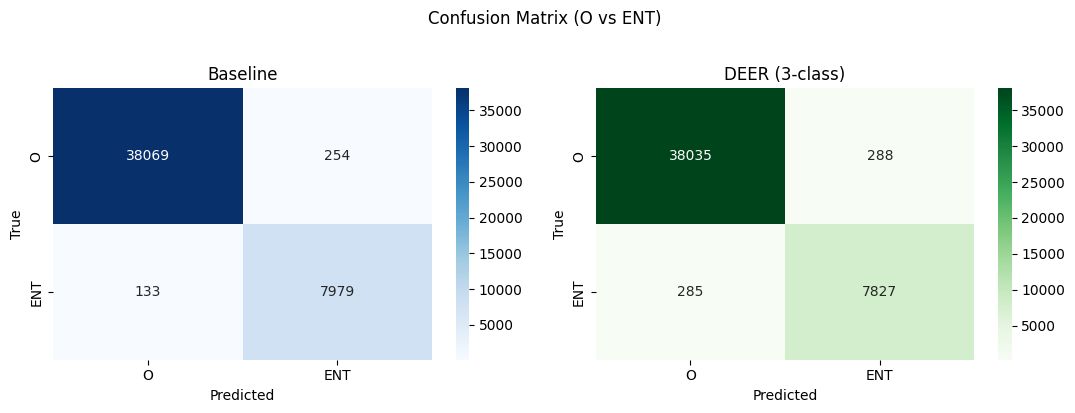

In [ ]:
def to_binary(seqs):
    return ["ENT" if t != "O" else "O" for seq in seqs for t in seq]

labels = ["O", "ENT"]
cm_b = pd.DataFrame(confusion_matrix(to_binary(y_true), to_binary(y_base), labels=labels), index=labels, columns=labels)
cm_d = pd.DataFrame(confusion_matrix(to_binary(y_true), to_binary(y_deer), labels=labels), index=labels, columns=labels)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm_b, annot=True, fmt="d", cmap="Blues",  ax=axes[0])
axes[0].set_title("Baseline")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_d, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("DEER (3-class)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.suptitle("Confusion Matrix (O vs ENT)", y=1.02)
plt.tight_layout()
plt.show()

## 9. Per-entity F1

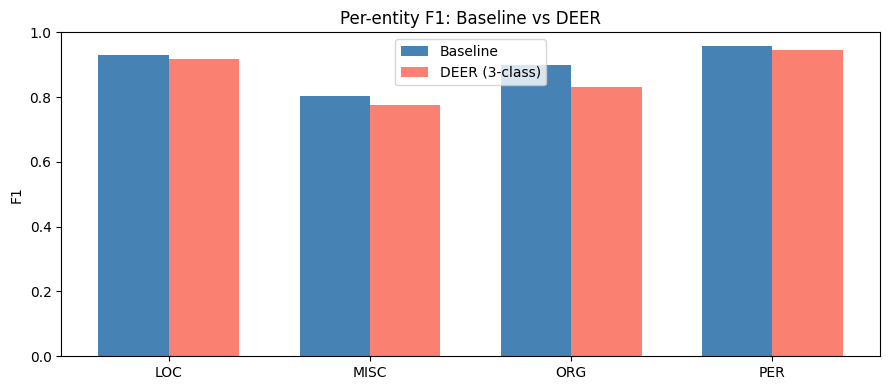

=== Baseline ===
              precision    recall  f1-score   support

         LOC     0.9321    0.9293    0.9307      1668
        MISC     0.7820    0.8276    0.8042       702
         ORG     0.8879    0.9109    0.8993      1661
         PER     0.9573    0.9573    0.9573      1617

   micro avg     0.9066    0.9193    0.9129      5648
   macro avg     0.8898    0.9063    0.8978      5648
weighted avg     0.9077    0.9193    0.9133      5648

=== DEER (3-class) ===
              precision    recall  f1-score   support

         LOC     0.9104    0.9257    0.9180      1668
        MISC     0.7390    0.8148    0.7751       702
         ORG     0.8040    0.8621    0.8321      1661
         PER     0.9445    0.9468    0.9456      1617

   micro avg     0.8650    0.8993    0.8818      5648
   macro avg     0.8495    0.8874    0.8677      5648
weighted avg     0.8676    0.8993    0.8829      5648



In [ ]:
def per_entity_f1(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {k: v["f1-score"] for k, v in report.items()
            if k not in ("micro avg", "macro avg", "weighted avg")}

base_f1_ent = per_entity_f1(y_true, y_base)
deer_f1_ent = per_entity_f1(y_true, y_deer)

ent_labels = sorted(base_f1_ent.keys())
x = np.arange(len(ent_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, [base_f1_ent[k] for k in ent_labels], w, label="Baseline",        color="steelblue")
ax.bar(x + w/2, [deer_f1_ent[k] for k in ent_labels], w, label="DEER (3-class)", color="salmon")
ax.set_xticks(x)
ax.set_xticklabels(ent_labels)
ax.set_ylim(0, 1)
ax.set_ylabel("F1")
ax.set_title("Per-entity F1: Baseline vs DEER")
ax.legend()
plt.tight_layout()
plt.show()

print("=== Baseline ===")
print(classification_report(y_true, y_base, digits=4))
print("=== DEER (3-class) ===")
print(classification_report(y_true, y_deer, digits=4))

## 10. Влияние context window

  window=0 → F1=0.8793
  window=1 → F1=0.8817
  window=2 → F1=0.8818
  window=3 → F1=0.8838


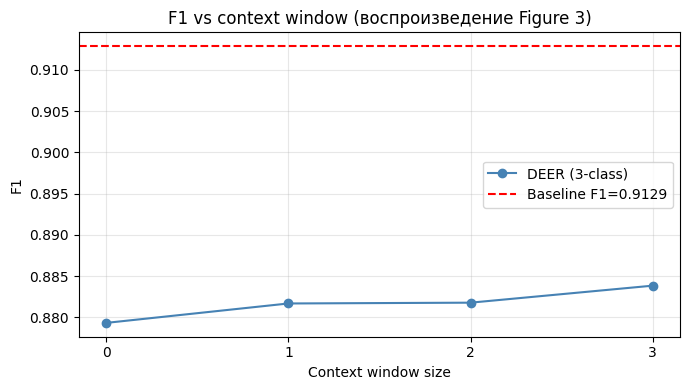

In [ ]:
windows    = [0, 1, 2, 3]
f1_by_win  = []

for win in windows:
    stats_w = build_token_stats(train_ds, LABEL_NAMES, window=win)
    y_d = [
        deer_correct(test_ds[i]["tokens"], y_base[i], stats_w)
        for i in range(len(test_ds))
    ]
    f1_by_win.append(f1_score(y_true, y_d))
    print(f"  window={win} → F1={f1_by_win[-1]:.4f}")

baseline_f1 = metrics["Baseline"]["F1"]

plt.figure(figsize=(7, 4))
plt.plot(windows, f1_by_win, marker="o", color="steelblue", label="DEER (3-class)")
plt.axhline(baseline_f1, color="red", linestyle="--", label=f"Baseline F1={baseline_f1:.4f}")
plt.xticks(windows)
plt.xlabel("Context window size")
plt.ylabel("F1")
plt.title("F1 vs context window (воспроизведение Figure 3)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Чувствительность к порогам

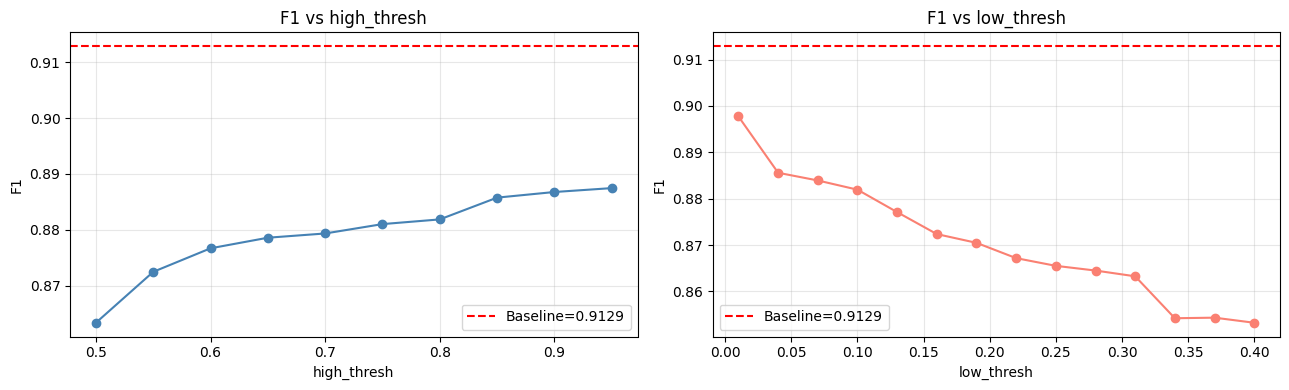

Лучший high_thresh: 0.95 → F1=0.8875
Лучший low_thresh:  0.01  → F1=0.8977


In [ ]:
high_range = np.arange(0.50, 1.0,  0.05)
low_range  = np.arange(0.01, 0.40, 0.03)

f1_high = [f1_score(y_true, [deer_correct(test_ds[i]["tokens"], y_base[i], token_stats, high=th)
                             for i in range(len(test_ds))])
           for th in high_range]

f1_low  = [f1_score(y_true, [deer_correct(test_ds[i]["tokens"], y_base[i], token_stats, low=th)
                             for i in range(len(test_ds))])
           for th in low_range]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(high_range, f1_high, marker="o", color="steelblue")
axes[0].axhline(baseline_f1, color="red", linestyle="--", label=f"Baseline={baseline_f1:.4f}")
axes[0].set_xlabel("high_thresh")
axes[0].set_ylabel("F1")
axes[0].set_title("F1 vs high_thresh")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(low_range, f1_low, marker="o", color="salmon")
axes[1].axhline(baseline_f1, color="red", linestyle="--", label=f"Baseline={baseline_f1:.4f}")
axes[1].set_xlabel("low_thresh")
axes[1].set_ylabel("F1")
axes[1].set_title("F1 vs low_thresh")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Лучший high_thresh: {high_range[np.argmax(f1_high)]:.2f} → F1={max(f1_high):.4f}")
print(f"Лучший low_thresh:  {low_range[np.argmax(f1_low)]:.2f}  → F1={max(f1_low):.4f}")

## 12. Анализ изменений

Всего изменений: 322
  Исправлено: 62
  Сломано:    240


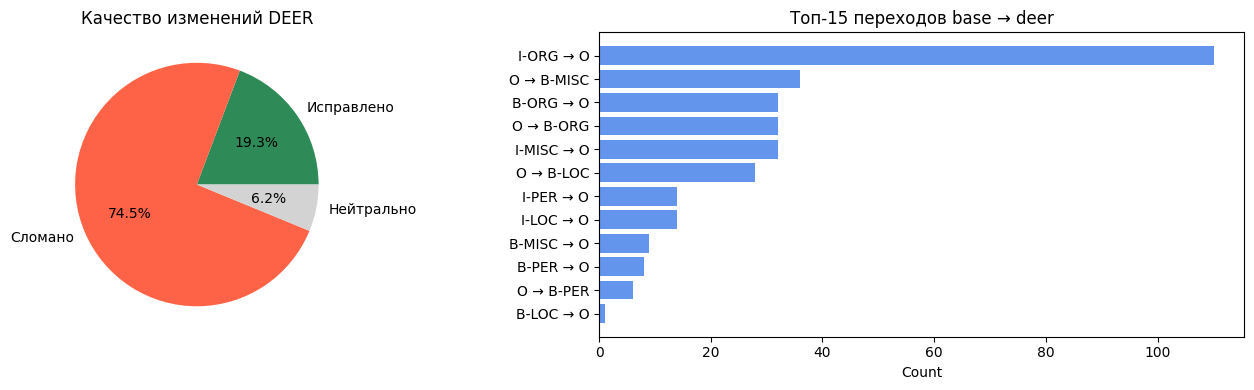

In [ ]:
changes = []
for i, ex in enumerate(test_ds):
    gold = [LABEL_NAMES[t] for t in ex["ner_tags"] ]
    for tok, g, b, d in zip(ex["tokens"], gold, y_base[i], y_deer[i]):
        if b != d:
            changes.append({
                "token": tok, "gold": g, "base": b, "deer": d,
                "fixed":  (d == g),
                "broken": (b == g and d != g),
            })

ch_df = pd.DataFrame(changes)
print(f"Всего изменений: {len(ch_df)}")
print(f"  Исправлено: {ch_df['fixed'].sum()}")
print(f"  Сломано:    {ch_df['broken'].sum()}")

transitions = (ch_df.groupby(["base", "deer"])
                     .size()
                     .reset_index(name="count")
                     .nlargest(15, "count"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

labels_pie = ["Исправлено", "Сломано", "Нейтрально"]
sizes_pie  = [
    ch_df["fixed"].sum(),
    ch_df["broken"].sum(),
    len(ch_df) - ch_df["fixed"].sum() - ch_df["broken"].sum()
]
axes[0].pie(sizes_pie, labels=labels_pie, autopct="%1.1f%%",
            colors=["seagreen", "tomato", "lightgray"])
axes[0].set_title("Качество изменений DEER")

transitions["label"] = transitions["base"] + " → " + transitions["deer"]
axes[1].barh(transitions["label"], transitions["count"], color="cornflowerblue")
axes[1].set_xlabel("Count")
axes[1].set_title("Топ-15 переходов base → deer")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 13. Заключение

**Что реализовано и что нет.**
Реализован Step 0 из статьи — трёхклассовая статистика (entity / context / other) с окном ±2, и упрощённый аналог Step 2 (false-negative коррекция по порогу). Step 1 (label-guided retrieval для LLM) и полноценный Step 2 с chain-of-thought промптами не реализованы — для этого нужен LLM API.

**Результаты.**
DEER-адаптация ухудшила все метрики относительно baseline:

| | F1 | Precision | Recall |
|---|---|---|---|
| Baseline | 0.9129 | 0.9066 | 0.9193 |
| DEER (3-class) | 0.8818 | 0.8650 | 0.8993 |
| Δ | −0.0311 | −0.0416 | −0.0200 |

Сильнее всего пострадала Precision — модель стала чаще ложно помечать токены как сущности. Из 322 изменений, которые внёс DEER, 240 (74.5%) оказались ошибочными и лишь 62 (19.3%) — верными.

**Per-entity F1.**
Baseline на отдельных типах: PER 0.957, LOC 0.931, ORG 0.899, MISC 0.804. DEER ухудшил все типы примерно равномерно — нет ни одной категории, где коррекция помогла.

**Context window ablation.**
С ростом окна F1 слегка увеличивается (0→0.8793, 1→0.8817, 2→0.8818, 3→0.8838), что совпадает с тrendом из Figure 3 статьи. Но все варианты хуже baseline — добавление context tokens меняет статистику, но сам механизм коррекции слишком грубый без LLM-инференса.

**Threshold sensitivity.**
Оптимальный `low_thresh=0.01` — фактически отключение правила "убрать предсказанную сущность". Оптимальный `high_thresh=0.95` означает, что срабатывать нужно только на очень уверенных токенах. Оба наблюдения говорят об одном: при сильной базовой модели любое вмешательство по статистике скорее вредит, чем помогает.

**Вывод.**
Идея DEER — использовать трёхклассовую label-статистику как сигнал — содержательная. Но в оригинале она работает как часть ICL-фреймворка: LLM при инференсе видит конкретный контекст предложения, reasoning-примеры и принимает решение с учётом всего этого. В нашей адаптации статистика применяется как глобальный порог без учёта контекста, что для fine-tuned BERT, который уже хорошо обучен, добавляет шум. Реальный прирост из статьи (до +8 F1 на OntoNotes с GPT-4o) достигается именно через LLM + label-guided retrieval, а не через постобработку.
